# 260528 — Atomblob+Density-ViT-MAE inspection

Companion to `260527_mae_atomblob.ipynb`. The pretext is the same — 60% block-masked MAE — but the encoder ingests a **12-channel** input: 7 ligand + 4 pocket atom voxels **plus the real X-ray 2Fo-Fc density** (locally ±3σ-clipped + z-scored). `density_source=xray`, `sigma_noise=0.0`, `input_mode=atomblob_density`.

Plots:
1. **Per-source sums** — ligand-sum (7-ch) / pocket-sum (4-ch) / density (1-ch) for ground truth | masked input | predicted | error, x/y/z planes.
2. **Per-channel** — all 12 channels (target / predicted / abs error) on a single slice axis.
3. **Quantitative split** — per-source MSE on atoms-present vs background voxels, and density-channel MSE.

**Diff vs the atomblob-only notebook:** the dataset is `DatasetCrossDockedXray` with `use_xray=True` (real density crops from `xray_crops_aligned/`), the input has an extra density channel concatenated at index 11, and the same 8³ block mask broadcasts across all 12 channels. Per-channel-12 has the density channel at the right edge of the grid.

In [1]:
# ── imports + paths ─────────────────────────────────────────────
import sys, os
VOX_ROOT = '/home/shpark/prj-denovo/VoxBind'
if VOX_ROOT not in sys.path:
    sys.path.insert(0, VOX_ROOT)

import numpy as np
import torch
import matplotlib.pyplot as plt
from omegaconf import OmegaConf

from voxbind.models.density_vit import DensityViTMAE
from voxbind.dataset.crossdocked_xray import DatasetCrossDockedXray
from voxbind.voxelizer import Voxelizer
from voxbind.constants import ELEMENTS_HASH_CROSSDOCKED

device = torch.device('cuda:5' if torch.cuda.is_available() else 'cpu')
torch.set_grad_enabled(False)
print('device:', device)

device: cuda:5


In [2]:
# ── knobs ───────────────────────────────────────────────────────
EXP_DIR = f'{VOX_ROOT}/voxbind/exps/260526_atomblob_density_vit_mae_40m_pretrain'
CKPT_PATH = f'{EXP_DIR}/checkpoint.pth.tar'    # or checkpoint_e0020.pth.tar / e0040 / …
DATA_DIR = f'{VOX_ROOT}/voxbind/dataset/data'
CROPS_DIR = f'{DATA_DIR}/xray_crops_aligned'

SAMPLE_IDX = 7        # which val sample to visualize (0..99); matches the atomblob notebook
SLICE_AXIS = 'z'      # 'x', 'y', or 'z' — for the per-channel grid
SLICE_OFFSET = 0      # offset from grid center (in voxels)
SEED_MASK = 0         # reproducible block mask  (same as atomblob / density MAE notebooks)

# Match the training config (configs/config_train_atomblob_density_vit_mae_40m.yaml > mae)
BLOCK_SIZE = 8
MASK_RATIO = 0.60
RESOLUTION = 0.25     # Å / voxel
GRID_DIM = 64
STRUCT_POS_THRESH = 0.05
print(f'mask: {MASK_RATIO:.2f} of {BLOCK_SIZE}³-voxel blocks zeroed; input is 12-ch (11 atoms + 1 density)')

mask: 0.60 of 8³-voxel blocks zeroed; input is 12-ch (11 atoms + 1 density)


In [3]:
# ── load model from checkpoint ─────────────────────────────────────
ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
cfg = ckpt['cfg'] if 'cfg' in ckpt else None
print('ckpt epoch:', ckpt.get('epoch'), '| global_step:', ckpt.get('global_step'))
if cfg is not None:
    print('model cfg:', OmegaConf.to_container(cfg.model, resolve=True))
    print('input_mode:', cfg.get('input_mode'), '| density_source:', cfg.mae.get('density_source'))

model = DensityViTMAE(
    grid_dim=int(cfg.vox.grid_dim) if cfg is not None else GRID_DIM,
    patch_size=int(cfg.model.patch_size) if cfg is not None else 8,
    n_in_channels=int(cfg.model.n_in_channels) if cfg is not None else 12,
    n_channels=int(cfg.model.n_channels) if cfg is not None else 32,
    dim=int(cfg.model.dim) if cfg is not None else 512,
    depth=int(cfg.model.depth) if cfg is not None else 12,
    n_heads=int(cfg.model.heads) if cfg is not None else 8,
    mlp_ratio=int(cfg.model.mlp_ratio) if cfg is not None else 4,
    dropout=float(cfg.model.dropout) if cfg is not None else 0.1,
    n_struct_channels=int(cfg.model.n_struct_channels) if cfg is not None else 0,
).to(device).eval()

sd = ckpt.get('state_dict_ema', ckpt.get('state_dict'))
sd = {k.replace('module.', '').replace('_orig_mod.', ''): v for k, v in sd.items()}
missing, unexpected = model.load_state_dict(sd, strict=False)
print('missing keys:', len(missing), '| unexpected keys:', len(unexpected))
print(f'params: {sum(p.numel() for p in model.parameters()) / 1e6:.3f}M')
print(f'token grid: {model.encoder.g_p}³ = {model.encoder.n_tokens} tokens; patch_size={model.encoder.patch_size}; in_channels={model.encoder.n_in_channels}')

ckpt epoch: 99 | global_step: 98000
model cfg: {'model_name': 'atomblob_density_vit_mae_40m', 'n_channels': 32, 'patch_size': 8, 'n_in_channels': 12, 'dim': 512, 'depth': 12, 'heads': 8, 'mlp_ratio': 4, 'dropout': 0.1, 'n_struct_channels': 0}
input_mode: atomblob_density | density_source: xray


missing keys: 0 | unexpected keys: 0
params: 45.453M
token grid: 8³ = 512 tokens; patch_size=8; in_channels=12


In [4]:
# ── load + voxelize one val sample (real X-ray density via xray_crops_aligned) ─────
dset_val = DatasetCrossDockedXray(
    data_dir=DATA_DIR,
    crops_dir=CROPS_DIR,
    split='val', aug=False, small=False,
    ligand_radius=0.5, pocket_radius=-1,
    use_xray=True,                    # load real 2Fo-Fc density
    normalize=True,                   # local ±3σ clip + z-score (matches training)
    subset_xray_only=True,
    subset_n=78428,
    subset_val_n=100,
)
print('val set size:', len(dset_val))
sample = dset_val[SAMPLE_IDX]
print('sample id:', sample['ligand']['id'], '|', sample['pocket']['id'])
print('xray density tensor:', tuple(sample['xray_density'].shape),
      f"mean={sample['xray_density'].mean().item():+.3f}  std={sample['xray_density'].std().item():.3f}")

voxelizer = Voxelizer(
    grid_dim=GRID_DIM, resolution=RESOLUTION, cubes_around=8, device=device,
)
lig = {k: sample['ligand'][k].unsqueeze(0).to(device)
       for k in ('coords', 'radius', 'atoms_channel')}
poc = {k: sample['pocket'][k].unsqueeze(0).to(device)
       for k in ('coords', 'radius', 'atoms_channel')}
v_lig = voxelizer(lig, num_channels=7)                                 # (1, 7, G, G, G)
v_poc = voxelizer(poc, num_channels=4)                                 # (1, 4, G, G, G)
d_xray = sample['xray_density'].unsqueeze(0).unsqueeze(0).to(device)   # (1, 1, G, G, G)
print('v_lig:', tuple(v_lig.shape), 'v_poc:', tuple(v_poc.shape), 'd_xray:', tuple(d_xray.shape))

val set size: 100
sample id: XYNA_BACSU_29_204_0/1c5h_A_rec_2dcy_dio_lig_tt_min_0.sdf | XYNA_BACSU_29_204_0/1c5h_A_rec_2dcy_dio_lig_tt_min_0_pocket10.pdb
xray density tensor: (64, 64, 64) mean=-0.013  std=0.952


v_lig: (1, 7, 64, 64, 64) v_poc: (1, 4, 64, 64, 64) d_xray: (1, 1, 64, 64, 64)


In [5]:
# ── assemble atomblob+density input + block mask ───────────────────────────────
x_clean = torch.cat([v_lig, v_poc, d_xray], dim=1)     # (1, 12, G, G, G); channel 11 = density
print('x_clean:', tuple(x_clean.shape))

g_mask = torch.Generator(device=device).manual_seed(SEED_MASK)
B, G = x_clean.shape[0], x_clean.shape[-1]
blocks = torch.rand(B, 1, G // BLOCK_SIZE, G // BLOCK_SIZE, G // BLOCK_SIZE,
                    device=device, generator=g_mask) < MASK_RATIO
mask = blocks.repeat_interleave(BLOCK_SIZE, 2)\
             .repeat_interleave(BLOCK_SIZE, 3)\
             .repeat_interleave(BLOCK_SIZE, 4)
# sigma_noise=0.0 in this run, so x_noisy = x_clean (no additive noise)
x_in = x_clean * (~mask).to(x_clean.dtype)             # broadcasts across all 12 channels

print(f'mask fraction (voxel): {mask.float().mean().item():.3f}  (target {MASK_RATIO})')
n_blocks = (G // BLOCK_SIZE) ** 3
n_blocks_masked = blocks.sum().item()
print(f'masked blocks: {n_blocks_masked}/{n_blocks}')
print(f'x_clean per-channel stats:')
for c in range(12):
    name = f'ch{c:02d}' + (' (density)' if c == 11 else '')
    print(f'  {name:>14}: min={x_clean[0,c].min().item():+.3f}  max={x_clean[0,c].max().item():+.3f}  '
          f"mean={x_clean[0,c].mean().item():+.4f}")

x_clean: (1, 12, 64, 64, 64)
mask fraction (voxel): 0.580  (target 0.6)
masked blocks: 297/512
x_clean per-channel stats:
            ch00: min=+0.000  max=+0.956  mean=+0.0005
            ch01: min=+0.000  max=+0.950  mean=+0.0003
            ch02: min=+0.000  max=+0.000  mean=+0.0000
            ch03: min=+0.000  max=+0.000  mean=+0.0000
            ch04: min=+0.000  max=+0.000  mean=+0.0000
            ch05: min=+0.000  max=+0.000  mean=+0.0000
            ch06: min=+0.000  max=+0.000  mean=+0.0000
            ch07: min=+0.000  max=+1.000  mean=+0.3021
            ch08: min=+0.000  max=+0.998  mean=+0.0831
            ch09: min=+0.000  max=+0.999  mean=+0.0721
            ch10: min=+0.000  max=+0.000  mean=+0.0000
  ch11 (density): min=-1.989  max=+3.000  mean=-0.0131


In [6]:
# ── forward through the model ───────────────────────────────────────
out_pretext, a_hat = model(x_in)
print('out_pretext:', tuple(out_pretext.shape), '   (B, 12, G, G, G) — reconstructed [atoms; density]')
print('a_hat       :', None if a_hat is None else tuple(a_hat.shape),
      '   (None because n_struct_channels=0)')

# Masked-voxel reconstruction loss, all 12 channels.
m = mask.to(out_pretext.dtype)
n_masked_spatial = m.sum().clamp(min=1.0)
diff_sq = (out_pretext - x_clean) ** 2 * m             # broadcast (B,1,G,G,G) over 12 channels
L_recon = diff_sq.sum() / (n_masked_spatial * out_pretext.shape[1])
L_atoms = diff_sq[:, :11].sum() / (n_masked_spatial * 11)
L_dens  = diff_sq[:, 11:].sum() / (n_masked_spatial * 1)
print(f'sample L_recon  (masked, all 12 ch): {L_recon.item():.5f}')
print(f'        L_atoms (masked, atom 11 ch): {L_atoms.item():.5f}')
print(f'        L_dens  (masked, density 1 ch): {L_dens.item():.5f}')

# Per-source split on atoms-present vs background voxels.
print(f'\nper-source split (threshold {STRUCT_POS_THRESH}):')
for name, tgt, pred in [
    ('lig', x_clean[0, :7],   out_pretext[0, :7]),
    ('poc', x_clean[0, 7:11], out_pretext[0, 7:11]),
]:
    pos = tgt > STRUCT_POS_THRESH
    pos_frac = pos.float().mean().item()
    mse_on  = ((pred[pos]  - tgt[pos])  ** 2).mean().item() if pos.any() else float('nan')
    mse_off = ((pred[~pos] - tgt[~pos]) ** 2).mean().item()
    print(
        f'  {name}: pos-frac={pos_frac:.4f}  '
        f'peak tgt={tgt.max().item():.3f} pred={pred.max().item():.3f}  '
        f'MSE@on={mse_on:.4f}  MSE@off={mse_off:.6f}'
    )

# Density-specific stats — different geometry (not atoms-binary; signed z-scored).
dens_tgt = x_clean[0, 11]
dens_prd = out_pretext[0, 11]
high = dens_tgt > 1.0    # high-density peaks (≥1σ above mean)
print(
    f'  dens: range tgt=[{dens_tgt.min().item():+.2f}, {dens_tgt.max().item():+.2f}]  '
    f'pred=[{dens_prd.min().item():+.2f}, {dens_prd.max().item():+.2f}]  '
    f'MSE@all={((dens_prd-dens_tgt)**2).mean().item():.4f}  '
    f'MSE@>1σ={((dens_prd[high]-dens_tgt[high])**2).mean().item():.4f}'
)

out_pretext: (1, 12, 64, 64, 64)    (B, 12, G, G, G) — reconstructed [atoms; density]
a_hat       : None    (None because n_struct_channels=0)
sample L_recon  (masked, all 12 ch): 0.00837
        L_atoms (masked, atom 11 ch): 0.00050
        L_dens  (masked, density 1 ch): 0.09498

per-source split (threshold 0.05):
  lig: pos-frac=0.0005  peak tgt=0.956 pred=0.159  MSE@on=0.0723  MSE@off=0.000008
  poc: pos-frac=0.2912  peak tgt=1.000 pred=1.061  MSE@on=0.0033  MSE@off=0.000192
  dens: range tgt=[-1.99, +3.00]  pred=[-1.73, +3.55]  MSE@all=0.0925  MSE@>1σ=0.3839


In [7]:
# ── slicing helpers ─────────────────────────────────────────────────
def take_slice(vol, axis='z', offset=0):
    arr = vol.detach().cpu().numpy() if torch.is_tensor(vol) else vol
    G = arr.shape[-1]
    idx = G // 2 + offset
    if axis == 'x':
        return arr[idx, :, :]
    elif axis == 'y':
        return arr[:, idx, :]
    elif axis == 'z':
        return arr[:, :, idx]
    raise ValueError(axis)

def show(ax, img, title, cmap='gray', vmin=None, vmax=None):
    im = ax.imshow(img.T, origin='lower', cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    return im

## Plot 1 — per-source: ligand-sum, pocket-sum, density across x/y/z planes

Columns: ground truth | masked input | predicted | (pred−GT)·mask. Three plots, one per source:
- Plot 1a: ligand-sum (7-ch collapsed)
- Plot 1b: pocket-sum (4-ch collapsed)
- Plot 1c: density (single channel, real 2Fo-Fc)

All three share the same mask, so the same masked blocks appear black in column 2 of every plot.

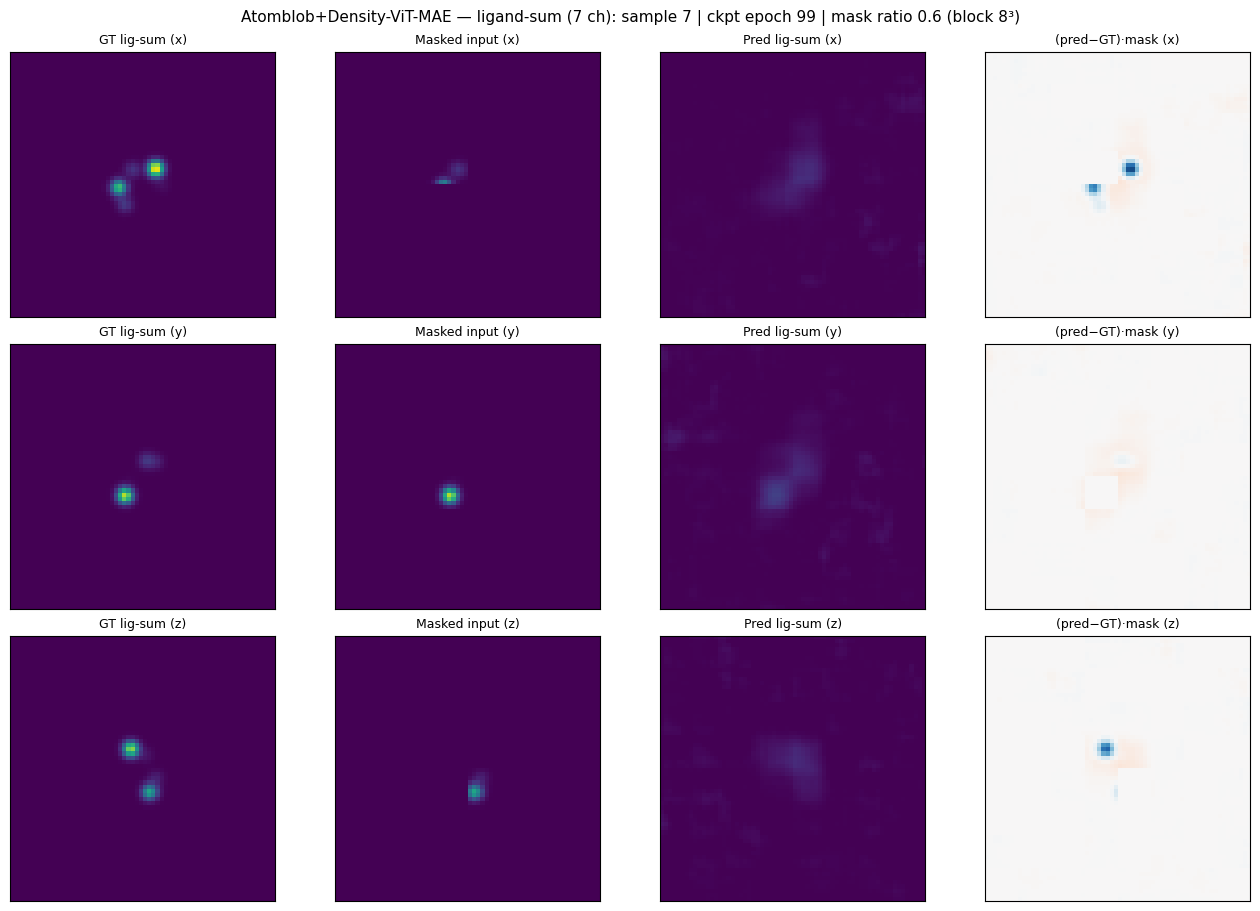

In [8]:
# ── plot 1a: ligand-sum (7 ch) GT | masked | pred | error, for x/y/z planes ───────────
mask_3d = mask[0, 0]
tgt_lig  = x_clean[0, :7].sum(0)
in_lig   = x_in[0, :7].sum(0)
pred_lig = out_pretext[0, :7].sum(0)
err_lig  = (out_pretext[0, :7] - x_clean[0, :7]).sum(0) * mask_3d.float()

vmax_lig = max(tgt_lig.max().item(), pred_lig.max().item(), 1e-3)
err_abs_lig = max(err_lig.abs().max().item(), 1e-3)

fig, axes = plt.subplots(3, 4, figsize=(13, 9), constrained_layout=True)
for i, ax_name in enumerate(['x', 'y', 'z']):
    show(axes[i, 0], take_slice(tgt_lig, ax_name, SLICE_OFFSET),
         f'GT lig-sum ({ax_name})',     cmap='viridis', vmin=0,            vmax=vmax_lig)
    show(axes[i, 1], take_slice(in_lig, ax_name, SLICE_OFFSET),
         f'Masked input ({ax_name})',  cmap='viridis', vmin=0,            vmax=vmax_lig)
    show(axes[i, 2], take_slice(pred_lig, ax_name, SLICE_OFFSET),
         f'Pred lig-sum ({ax_name})',  cmap='viridis', vmin=0,            vmax=vmax_lig)
    show(axes[i, 3], take_slice(err_lig, ax_name, SLICE_OFFSET),
         f'(pred−GT)·mask ({ax_name})', cmap='RdBu_r', vmin=-err_abs_lig, vmax=err_abs_lig)
fig.suptitle(
    f"Atomblob+Density-ViT-MAE — ligand-sum (7 ch): sample {SAMPLE_IDX} | ckpt epoch {ckpt.get('epoch')} | "
    f"mask ratio {MASK_RATIO} (block {BLOCK_SIZE}³)",
    fontsize=11,
)
plt.show()

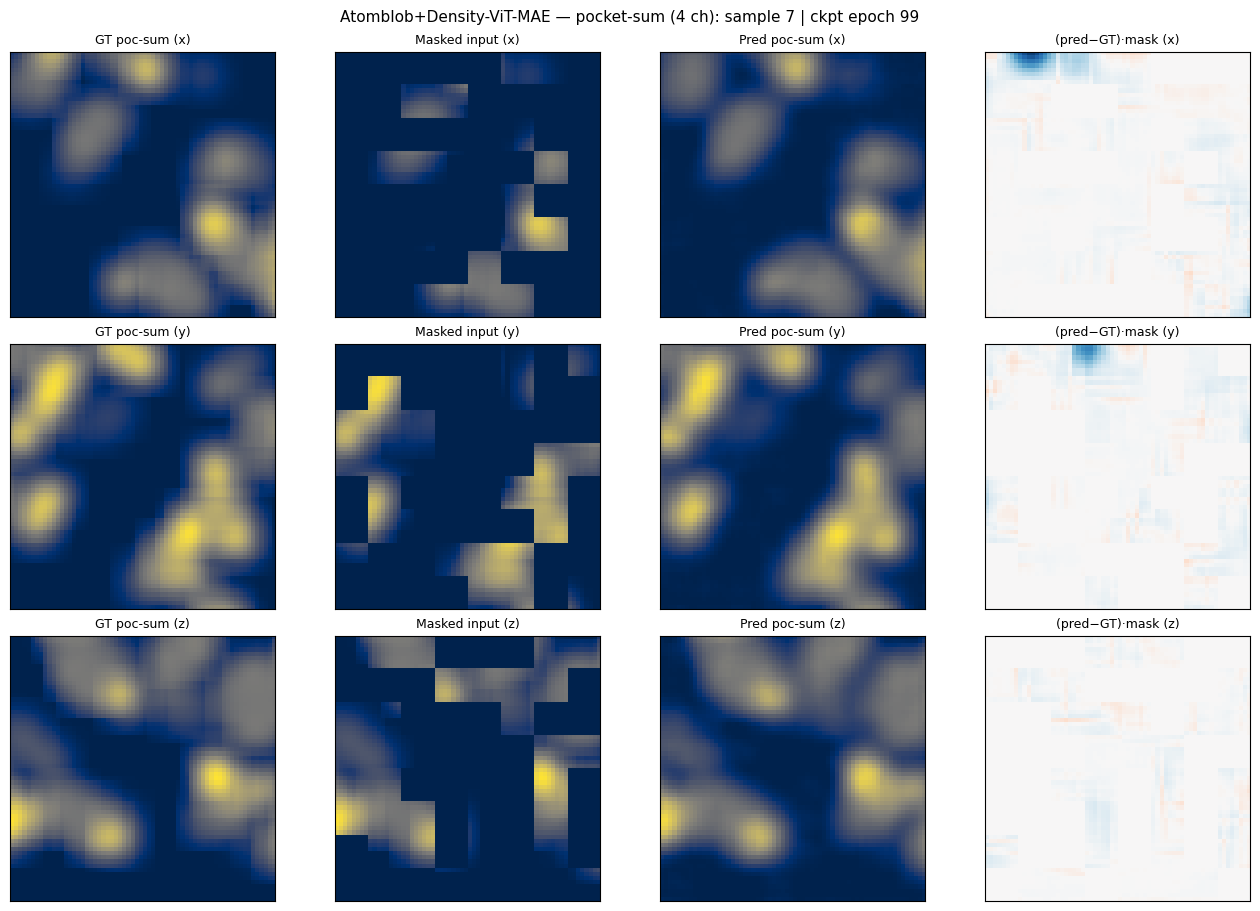

In [9]:
# ── plot 1b: pocket-sum (4 ch) GT | masked | pred | error, for x/y/z planes ───────────
tgt_poc  = x_clean[0, 7:11].sum(0)
in_poc   = x_in[0, 7:11].sum(0)
pred_poc = out_pretext[0, 7:11].sum(0)
err_poc  = (out_pretext[0, 7:11] - x_clean[0, 7:11]).sum(0) * mask_3d.float()

vmax_poc = max(tgt_poc.max().item(), pred_poc.max().item(), 1e-3)
err_abs_poc = max(err_poc.abs().max().item(), 1e-3)

fig, axes = plt.subplots(3, 4, figsize=(13, 9), constrained_layout=True)
for i, ax_name in enumerate(['x', 'y', 'z']):
    show(axes[i, 0], take_slice(tgt_poc, ax_name, SLICE_OFFSET),
         f'GT poc-sum ({ax_name})',     cmap='cividis', vmin=0,            vmax=vmax_poc)
    show(axes[i, 1], take_slice(in_poc, ax_name, SLICE_OFFSET),
         f'Masked input ({ax_name})',  cmap='cividis', vmin=0,            vmax=vmax_poc)
    show(axes[i, 2], take_slice(pred_poc, ax_name, SLICE_OFFSET),
         f'Pred poc-sum ({ax_name})',  cmap='cividis', vmin=0,            vmax=vmax_poc)
    show(axes[i, 3], take_slice(err_poc, ax_name, SLICE_OFFSET),
         f'(pred−GT)·mask ({ax_name})', cmap='RdBu_r', vmin=-err_abs_poc, vmax=err_abs_poc)
fig.suptitle(
    f"Atomblob+Density-ViT-MAE — pocket-sum (4 ch): sample {SAMPLE_IDX} | ckpt epoch {ckpt.get('epoch')}",
    fontsize=11,
)
plt.show()

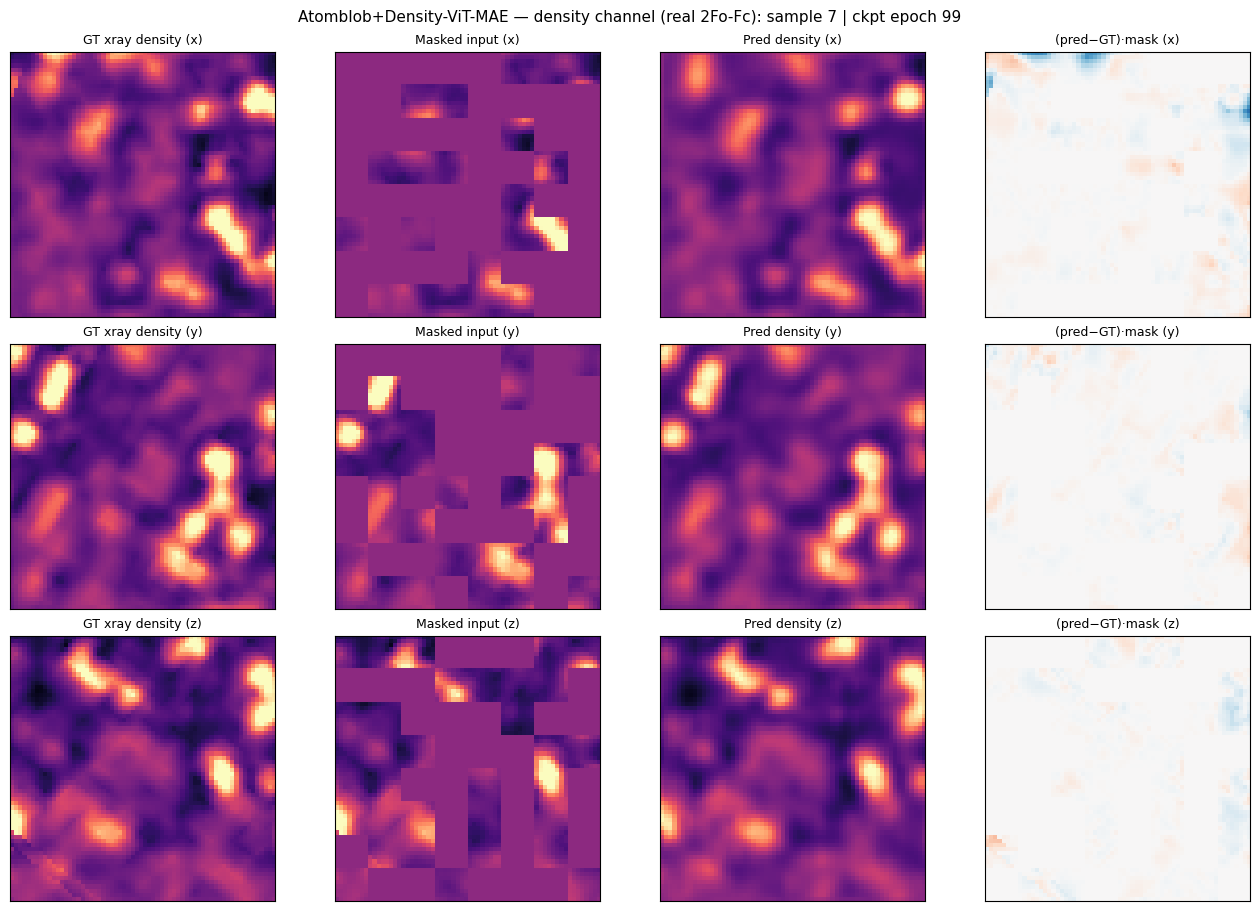

In [10]:
# ── plot 1c: density channel (real 2Fo-Fc) GT | masked | pred | error, for x/y/z ──────
tgt_dens  = x_clean[0, 11]
in_dens   = x_in[0, 11]
pred_dens = out_pretext[0, 11]
err_dens  = (pred_dens - tgt_dens) * mask_3d.float()

vlo = tgt_dens.min().item()
vhi = tgt_dens.max().item()
err_abs_d = max(err_dens.abs().max().item(), 1e-3)

fig, axes = plt.subplots(3, 4, figsize=(13, 9), constrained_layout=True)
for i, ax_name in enumerate(['x', 'y', 'z']):
    show(axes[i, 0], take_slice(tgt_dens, ax_name, SLICE_OFFSET),
         f'GT xray density ({ax_name})', cmap='magma', vmin=vlo, vmax=vhi)
    show(axes[i, 1], take_slice(in_dens, ax_name, SLICE_OFFSET),
         f'Masked input ({ax_name})',    cmap='magma', vmin=vlo, vmax=vhi)
    show(axes[i, 2], take_slice(pred_dens, ax_name, SLICE_OFFSET),
         f'Pred density ({ax_name})',    cmap='magma', vmin=vlo, vmax=vhi)
    show(axes[i, 3], take_slice(err_dens, ax_name, SLICE_OFFSET),
         f'(pred−GT)·mask ({ax_name})',  cmap='RdBu_r', vmin=-err_abs_d, vmax=err_abs_d)
fig.suptitle(
    f"Atomblob+Density-ViT-MAE — density channel (real 2Fo-Fc): sample {SAMPLE_IDX} | ckpt epoch {ckpt.get('epoch')}",
    fontsize=11,
)
plt.show()

## Plot 2 — per-channel target / predicted / abs-error

All 12 channels on a single slice (`SLICE_AXIS`, `SLICE_OFFSET`). Channel labels: 7 ligand element-channels, 4 pocket element-channels, then the density channel at index 11.

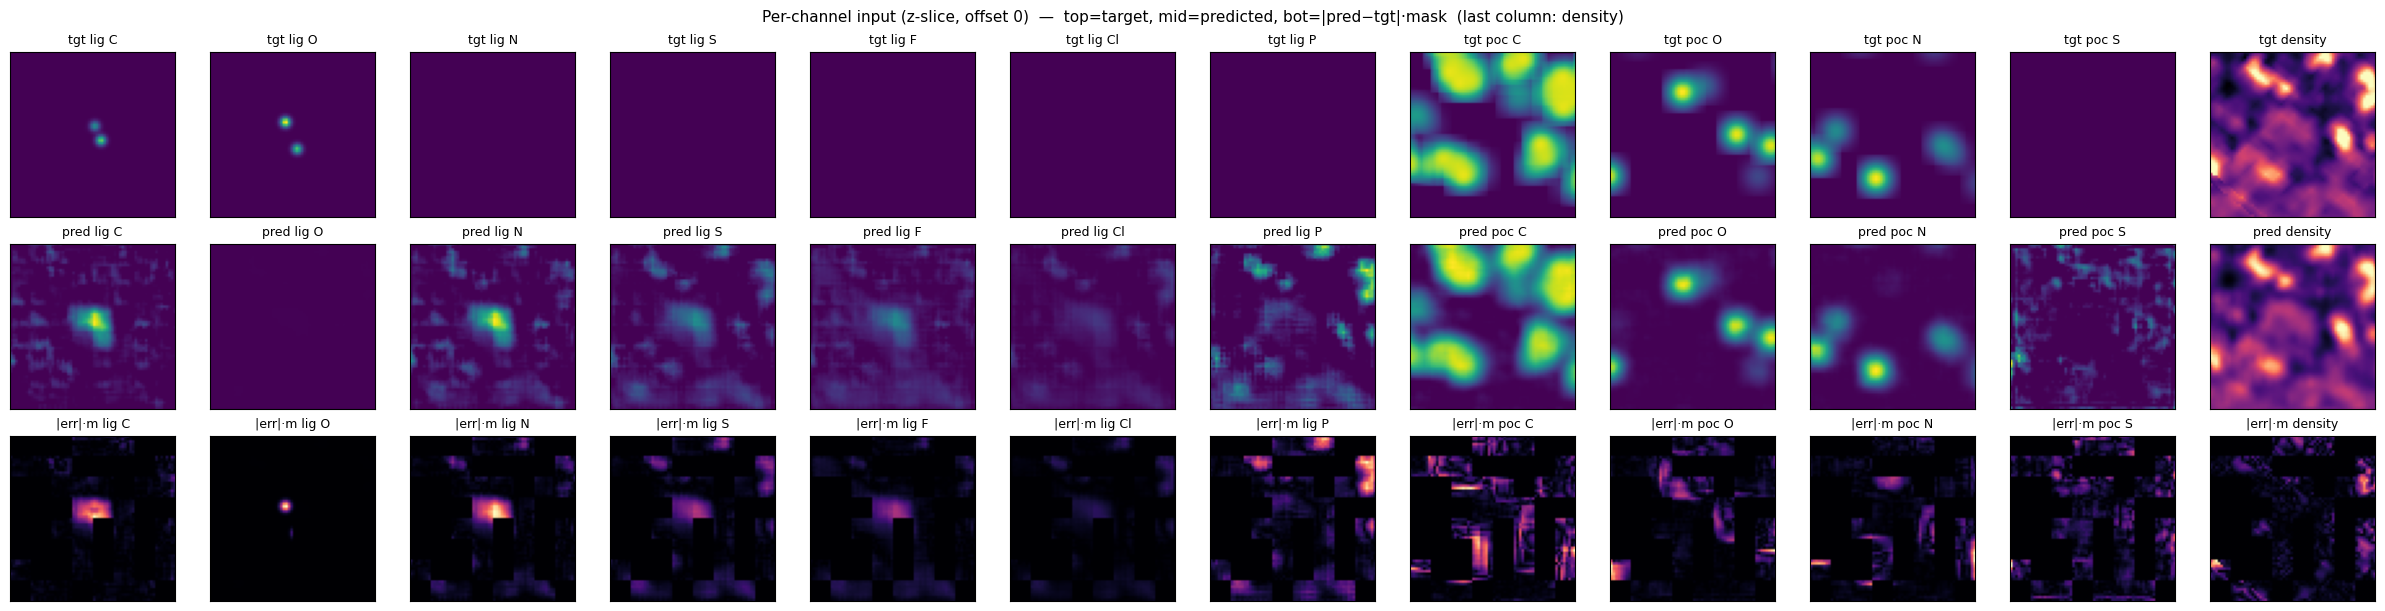

In [11]:
# ── per-channel grid: 3 rows × 12 cols (target / pred / |error|*mask) ──────────────
elem_names = list(ELEMENTS_HASH_CROSSDOCKED.keys())
lig_names = [f'lig {elem_names[i]}' for i in range(7)]
poc_names = [f'poc {elem_names[i]}' for i in range(4)]
chan_names = lig_names + poc_names + ['density']

fig, axes = plt.subplots(3, 12, figsize=(24, 6.0), constrained_layout=True)
for c in range(12):
    tgt  = take_slice(x_clean[0, c],     SLICE_AXIS, SLICE_OFFSET)
    pred = take_slice(out_pretext[0, c], SLICE_AXIS, SLICE_OFFSET)
    err  = take_slice(
        ((out_pretext[0, c] - x_clean[0, c]).abs() * mask_3d.float()),
        SLICE_AXIS, SLICE_OFFSET,
    )
    # density (c==11) is signed/z-scored; atoms are non-negative
    if c < 11:
        vmin, vmax = 0.0, max(float(tgt.max()), float(pred.max()), 1e-3)
        cmap_tp = 'viridis'
    else:
        vmin, vmax = float(tgt.min()), float(tgt.max())
        cmap_tp = 'magma'
    show(axes[0, c], tgt,  f'tgt {chan_names[c]}',  cmap=cmap_tp, vmin=vmin, vmax=vmax)
    show(axes[1, c], pred, f'pred {chan_names[c]}', cmap=cmap_tp, vmin=vmin, vmax=vmax)
    show(axes[2, c], err,  f'|err|·m {chan_names[c]}', cmap='magma',
         vmin=0, vmax=max(float(err.max()), 1e-3))
fig.suptitle(
    f'Per-channel input ({SLICE_AXIS}-slice, offset {SLICE_OFFSET})  —  '
    f'top=target, mid=predicted, bot=|pred−tgt|·mask  (last column: density)',
    fontsize=11,
)
plt.show()

## Plot 3 — voxel-value distributions (masked positions only)

Three histograms on masked voxels, separated by source. Atom channels: target vs predicted on atoms-present positions. Density channel: full target vs predicted distribution (signed, z-scored).

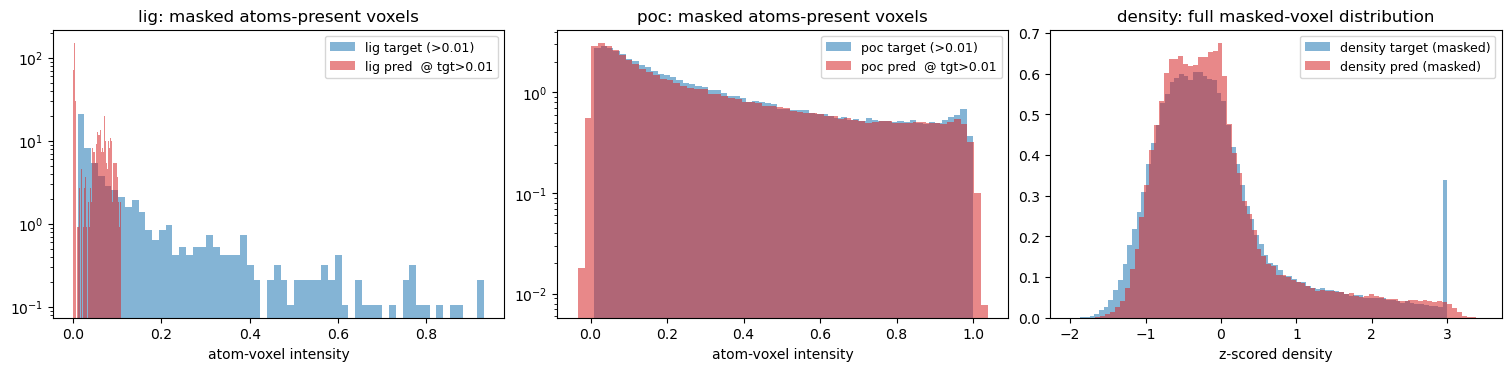

In [12]:
# ── histograms: per-source target vs predicted on masked voxels ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6), constrained_layout=True)

m_bool_flat = mask[0, 0].bool().flatten().cpu()
for ax, (name, tgt_full, pred_full) in zip(
    axes[:2],
    [('lig', x_clean[0, :7],   out_pretext[0, :7]),
     ('poc', x_clean[0, 7:11], out_pretext[0, 7:11])],
):
    tgt_flat  = tgt_full.flatten(1).cpu()[:, m_bool_flat].flatten().numpy()
    pred_flat = pred_full.flatten(1).cpu()[:, m_bool_flat].flatten().numpy()
    sel = tgt_flat > 0.01
    ax.hist(tgt_flat[sel],  bins=60, alpha=0.55, color='C0', density=True,
            label=f'{name} target (>0.01)')
    ax.hist(pred_flat[sel], bins=60, alpha=0.55, color='C3', density=True,
            label=f'{name} pred  @ tgt>0.01')
    ax.set_yscale('log')
    ax.set_xlabel('atom-voxel intensity')
    ax.legend(fontsize=9)
    ax.set_title(f'{name}: masked atoms-present voxels')

# density histogram: full distribution on masked voxels (signed, z-scored)
tgt_d_flat  = x_clean[0, 11].flatten().cpu()[m_bool_flat].numpy()
pred_d_flat = out_pretext[0, 11].flatten().cpu()[m_bool_flat].numpy()
axes[2].hist(tgt_d_flat,  bins=80, alpha=0.55, color='C0', density=True, label='density target (masked)')
axes[2].hist(pred_d_flat, bins=80, alpha=0.55, color='C3', density=True, label='density pred (masked)')
axes[2].set_xlabel('z-scored density')
axes[2].legend(fontsize=9)
axes[2].set_title('density: full masked-voxel distribution')
plt.show()

## Notes

* `SAMPLE_IDX` ∈ [0, 99]. Re-run cells 4–end to swap sample.
* `CKPT_PATH` defaults to the rolling `checkpoint.pth.tar` — point to e.g. `checkpoint_e0020.pth.tar` to inspect earlier epochs.
* `SEED_MASK=0` matches the atomblob and density-MAE inspect notebooks so the same voxel patches are masked across all three input-mode variants — direct A/B/C visual comparison.
* The model returns `(out_pretext, a_hat)` with `a_hat is None` because `n_struct_channels=0`. The pretext output is a 12-channel reconstruction: 7 ligand + 4 pocket + 1 density.
* `x_noisy = x_clean` in this variant (`sigma_noise = 0.0`) — the only corruption is the block mask.
* The density channel is the **real X-ray 2Fo-Fc** crop from `xray_crops_aligned/` (locally ±3σ-clipped + z-scored upstream by `DatasetCrossDockedXray.normalize_crop`), not the synthetic Gaussian-blur used in the density-only MAE runs.

### What to look for vs the atomblob-only run

* **Atom reconstruction**: per-channel ligand/pocket panels should be at least as good as the atomblob-only model — the encoder gets the same atom voxels plus *extra* density signal.
* **Density reconstruction**: this is the channel the atomblob-only model never saw. The MSE@>1σ row in cell 6 quantifies how well the model recovers density peaks (which are co-located with atoms).
* **Cross-modal cue**: in regions where the atom mask hits an atomic site, the density column at the same patches should still be informative (since density is also masked at those blocks — same mask broadcasts). Errors in plot 1c that line up with high-atom-mass regions in plots 1a/1b indicate the model can't fully infer density from neighbors alone.